# Anomaly Class Exploration

**Key info:**
- `training_batch_with_labels` (Set 0): 2 anomaly sub-classes within label=1
- `first_batch_with_labels` (Set 1): additional anomaly sub-classes
- Combined (Set 0 + Set 1): 4 anomaly sub-classes total
- Both share the same label scheme (0=normal, 1=anomaly), so sub-classes are latent

**Goal:** Compress the sparse feature data into dense representations and visualize to uncover the hidden anomaly sub-clusters.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Load data
# Set 1 = first_batch_with_labels
# Set 0 = training_batch_with_labels (2 anomaly classes)
f_set0 = np.load("../../ORIGINAL MATS DONT MODIFY/training_batch_with_labels.npz")
f_set1 = np.load("../../ORIGINAL MATS DONT MODIFY/first_batch_with_labels.npz")
f_set0_1 = np.load("../../ORIGINAL MATS DONT MODIFY/Labelled_0_1.npz")

print(
    "Set 0 - training_batch (2 anomaly classes) - X:",
    f_set0["X"].shape,
    "y:",
    f_set0["y"].shape,
)
print(
    "Set 1 - first_batch    (another 2 classes) - X:",
    f_set1["X"].shape,
    "y:",
    f_set1["y"].shape,
)
print("Set 1 and 0 - combined - X:", f_set0_1["X"].shape, "y:", f_set0_1["y"].shape)


def _extract_labels(y):
    y = np.asarray(y)
    return y[:, 1] if y.ndim == 2 and y.shape[1] >= 2 else y.ravel()

print("=" * 100)
for name, y_raw in [
    ("Set 0", f_set0["y"]),
    ("Set 1", f_set1["y"]),
    ("Combined (Set 0 + Set 1)", f_set0_1["y"]),
]:
    y_lbl = _extract_labels(y_raw)
    anomaly_pct = (y_lbl == 1).mean() * 100
    print(
        f"{name} anomaly percentage: {anomaly_pct:.2f}% ({(y_lbl == 1).sum()}/{len(y_lbl)})"
    )

Set 0 - training_batch (2 anomaly classes) - X: (177346, 3) y: (1100, 2)
Set 1 - first_batch    (another 2 classes) - X: (167493, 3) y: (1100, 2)
Set 1 and 0 - combined - X: (344839, 3) y: (2200, 2)
Set 0 anomaly percentage: 9.09% (100/1100)
Set 1 anomaly percentage: 9.09% (100/1100)
Combined (Set 0 + Set 1) anomaly percentage: 9.09% (200/2200)


## 1. Convert Sparse Triplets to Dense Feature Matrices

Each row in X is `(id, feature_index, value)` — a sparse representation. We convert each ID into a dense 1000-dim vector.

In [18]:
def sparse_to_dense(X_sparse, y_labels):
    """Convert (id, feature_idx, value) triplets to dense matrix + aligned labels."""
    ids = np.unique(X_sparse[:, 0])
    id_to_row = {uid: i for i, uid in enumerate(ids)}
    
    n_samples = len(ids)
    n_features = X_sparse[:, 1].max() + 1
    
    dense = np.zeros((n_samples, n_features), dtype=np.float32)
    for row in X_sparse:
        dense[id_to_row[row[0]], row[1]] = row[2]
    
    # Align labels
    label_dict = dict(y_labels)
    labels = np.array([label_dict[uid] for uid in ids])
    
    return dense, labels, ids

# Convert both sets
X0_dense, y0, ids0 = sparse_to_dense(f_set0['X'], f_set0['y'])
X1_dense, y1, ids1 = sparse_to_dense(f_set1['X'], f_set1['y'])

print(f"Set 0 (training_batch) dense: {X0_dense.shape}, anomalies: {y0.sum()}/{len(y0)}")
print(f"Set 1 (first_batch)    dense: {X1_dense.shape}, anomalies: {y1.sum()}/{len(y1)}")

# Merge everything — combined has 4 anomaly sub-classes
X_all = np.concatenate([X0_dense, X1_dense], axis=0)
y_all = np.concatenate([y0, y1], axis=0)
source = np.array(['set0'] * len(y0) + ['set1'] * len(y1))

print(f"\nCombined dense: {X_all.shape} (4 anomaly sub-classes total)")

Set 0 (training_batch) dense: (1100, 1000), anomalies: 100/1100
Set 1 (first_batch)    dense: (1100, 1000), anomalies: 100/1100

Combined dense: (2200, 1000) (4 anomaly sub-classes total)


## 2. Label Distribution Comparison

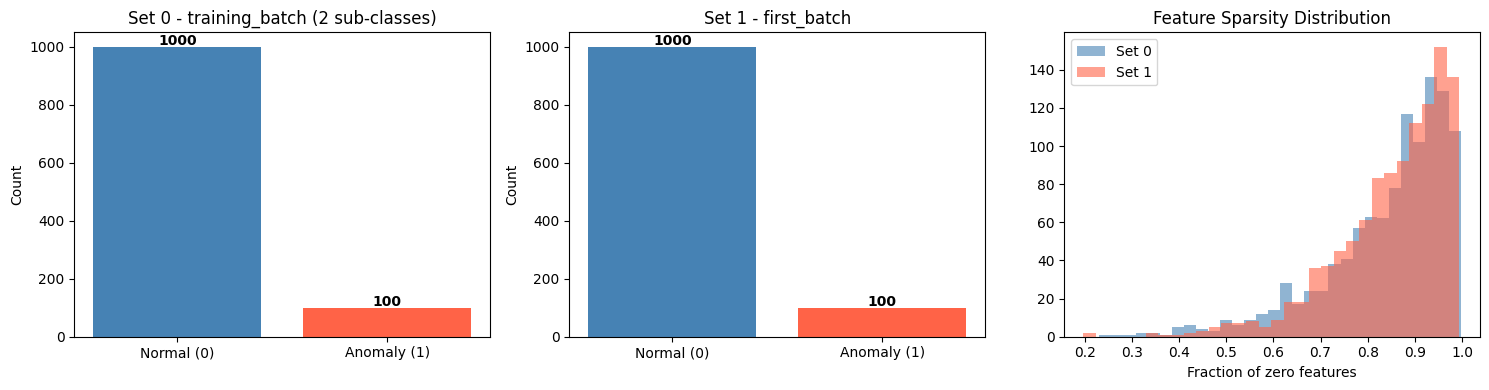

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Per-set label counts
for ax, (name, labels) in zip(axes[:2], [('Set 0 - training_batch (2 sub-classes)', y0), ('Set 1 - first_batch', y1)]):
    vals, counts = np.unique(labels, return_counts=True)
    ax.bar(['Normal (0)', 'Anomaly (1)'], counts, color=['steelblue', 'tomato'])
    ax.set_title(name)
    ax.set_ylabel('Count')
    for i, (v, c) in enumerate(zip(vals, counts)):
        ax.text(i, c + 5, str(c), ha='center', fontweight='bold')

# Feature sparsity comparison
sparsity0 = (X0_dense == 0).mean(axis=1)
sparsity1 = (X1_dense == 0).mean(axis=1)
axes[2].hist(sparsity0, bins=30, alpha=0.6, label='Set 0', color='steelblue')
axes[2].hist(sparsity1, bins=30, alpha=0.6, label='Set 1', color='tomato')
axes[2].set_title('Feature Sparsity Distribution')
axes[2].set_xlabel('Fraction of zero features')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction: PCA

Reduce the 1000-dim feature space to see if anomaly sub-clusters emerge.

Components for 90% variance: 1


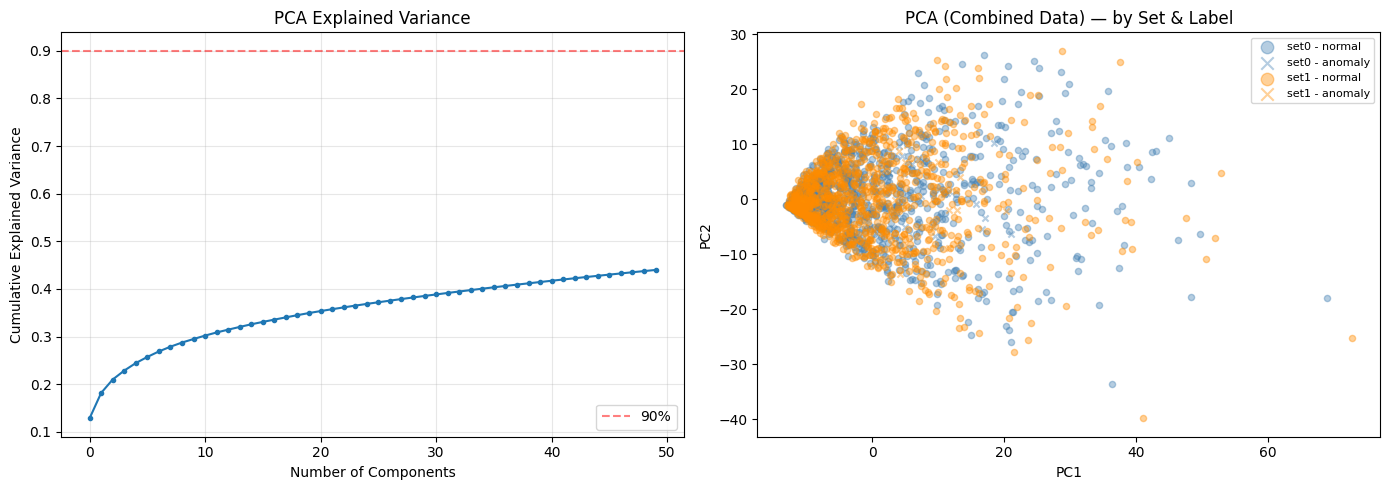

In [20]:
# PCA on all data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance
axes[0].plot(np.cumsum(pca.explained_variance_ratio_), 'o-', markersize=3)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Explained Variance')
axes[0].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1
print(f"Components for 90% variance: {n_90}")

# PCA 2D scatter: normal vs anomaly, colored by source set
colors = {'set0': 'steelblue', 'set1': 'darkorange'}
markers = {0: 'o', 1: 'x'}
for src in ['set0', 'set1']:
    for label in [0, 1]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} - {'anomaly' if label else 'normal'}"
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=colors[src], marker=markers[label],
                       alpha=0.4, s=20, label=lbl)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA (Combined Data) — by Set & Label')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

## 4. t-SNE on Anomalies Only

Focus on just the anomaly samples to see if sub-clusters are separable. We expect:
- 2 clusters from Set 0 (training_batch) anomalies
- Additional clusters appearing when Set 1 anomalies are included
- 4 total clusters in the combined data

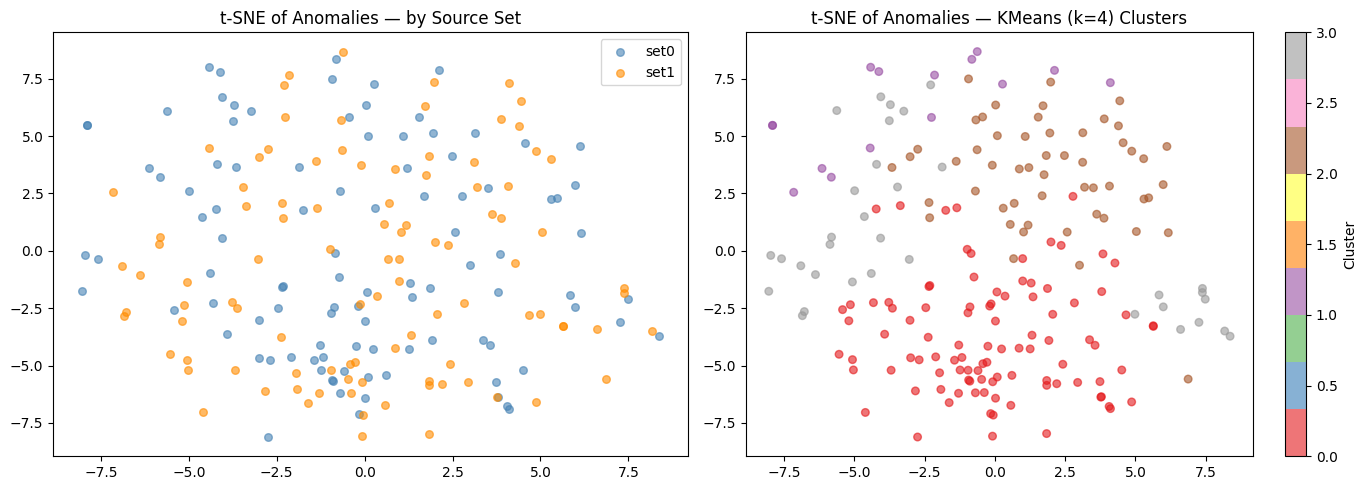


Cluster composition (source set):
  Cluster 0: 49 set0, 49 set1 (total 98)
  Cluster 1: 9 set0, 6 set1 (total 15)
  Cluster 2: 23 set0, 30 set1 (total 53)
  Cluster 3: 19 set0, 15 set1 (total 34)


In [21]:
# t-SNE on anomalies only (using PCA-reduced features for speed)
anomaly_mask = y_all == 1
X_anom_pca = X_pca[anomaly_mask]
source_anom = source[anomaly_mask]

tsne_anom = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_anom_tsne = tsne_anom.fit_transform(X_anom_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by source set
for src, color in [('set0', 'steelblue'), ('set1', 'darkorange')]:
    mask = source_anom == src
    axes[0].scatter(X_anom_tsne[mask, 0], X_anom_tsne[mask, 1],
                   c=color, alpha=0.6, s=30, label=f'{src}')
axes[0].set_title('t-SNE of Anomalies — by Source Set')
axes[0].legend()

# KMeans with k=4 to find sub-clusters
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_anom_pca)

scatter = axes[1].scatter(X_anom_tsne[:, 0], X_anom_tsne[:, 1],
                          c=cluster_labels, cmap='Set1', alpha=0.6, s=30)
axes[1].set_title('t-SNE of Anomalies — KMeans (k=4) Clusters')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Report cluster composition
print("\nCluster composition (source set):")
for c in range(4):
    mask = cluster_labels == c
    n_set0 = (source_anom[mask] == 'set0').sum()
    n_set1 = (source_anom[mask] == 'set1').sum()
    print(f"  Cluster {c}: {n_set0} set0, {n_set1} set1 (total {mask.sum()})")

## 5. t-SNE on All Data (Normal + Anomaly)

Full picture with all samples to see how anomaly sub-types relate to normal samples.

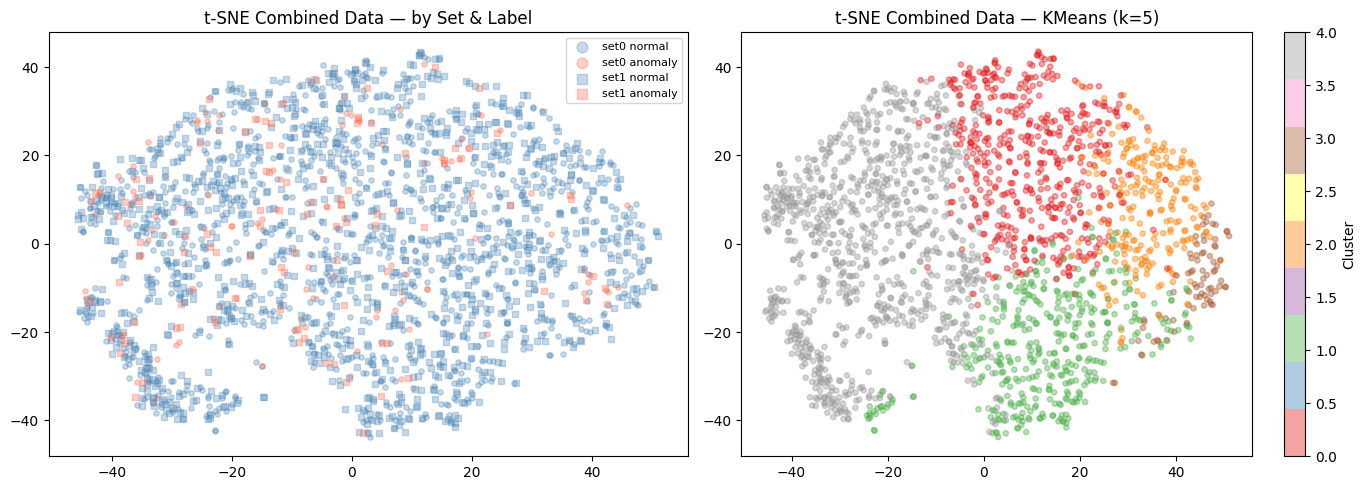

Cluster composition:
  Cluster 0: 464 normal, 50 anomaly (21 set0, 29 set1)
  Cluster 1: 383 normal, 25 anomaly (16 set0, 9 set1)
  Cluster 2: 225 normal, 11 anomaly (6 set0, 5 set1)
  Cluster 3: 74 normal, 3 anomaly (2 set0, 1 set1)
  Cluster 4: 854 normal, 111 anomaly (55 set0, 56 set1)


In [24]:
# t-SNE on all data
tsne_all = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_all_tsne = tsne_all.fit_transform(X_pca[:, :20])  # Use top 20 PCs for speed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By label + source set
for src, marker in [('set0', 'o'), ('set1', 's')]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[0].scatter(X_all_tsne[mask, 0], X_all_tsne[mask, 1],
                       c=color, marker=marker, alpha=0.3, s=15, label=lbl)
axes[0].set_title('t-SNE Combined Data — by Set & Label')
axes[0].legend(markerscale=2, fontsize=8)

# KMeans k=5 on all data (1 normal + 4 anomaly types)
km_all = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_all = km_all.fit_predict(X_pca[:, :20])
scatter = axes[1].scatter(X_all_tsne[:, 0], X_all_tsne[:, 1],
                          c=clusters_all, cmap='Set1', alpha=0.4, s=15)
axes[1].set_title('t-SNE Combined Data — KMeans (k=5)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Cluster composition
print("Cluster composition:")
for c in range(5):
    mask = clusters_all == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == 'set0') & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == 'set1') & (y_all[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1)")

## 6. UMAP on Anomalies Only

UMAP preserves more global structure than t-SNE and is faster. Same analysis as section 4 but with UMAP embeddings.

c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


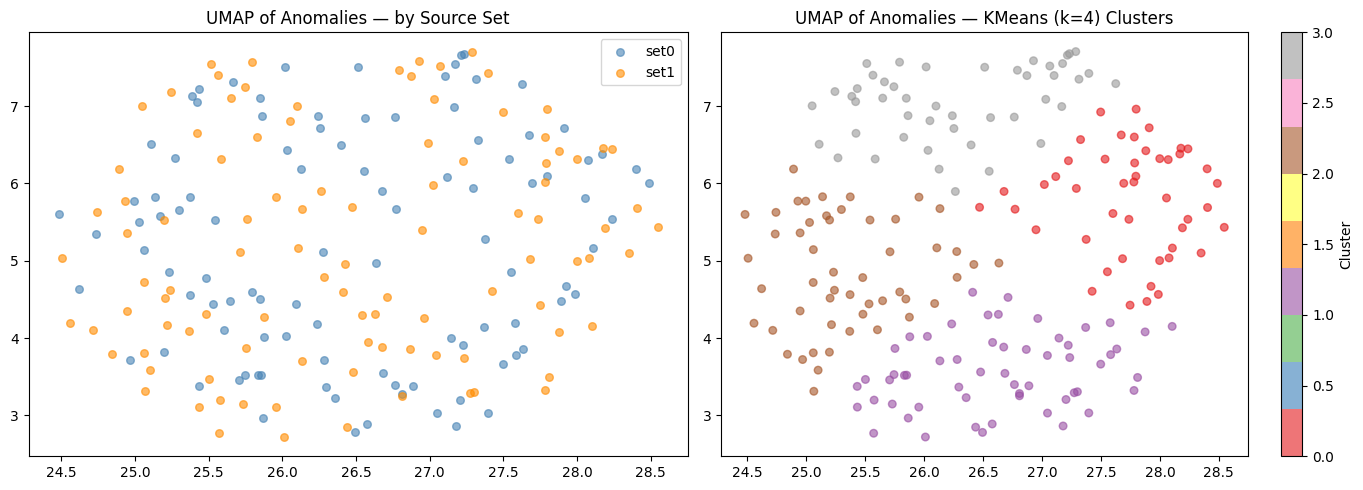


UMAP cluster composition (source set):
  Cluster 0: 22 set0, 24 set1 (total 46)
  Cluster 1: 29 set0, 28 set1 (total 57)
  Cluster 2: 24 set0, 27 set1 (total 51)
  Cluster 3: 25 set0, 21 set1 (total 46)


In [26]:
import umap

# UMAP on anomalies only (using PCA-reduced features)
umap_anom = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_anom_umap = umap_anom.fit_transform(X_anom_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by source set
for src, color in [('set0', 'steelblue'), ('set1', 'darkorange')]:
    mask = source_anom == src
    axes[0].scatter(X_anom_umap[mask, 0], X_anom_umap[mask, 1],
                   c=color, alpha=0.6, s=30, label=f'{src}')
axes[0].set_title('UMAP of Anomalies — by Source Set')
axes[0].legend()

# KMeans with k=4 to find sub-clusters
km_umap = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_umap = km_umap.fit_predict(X_anom_umap)

scatter = axes[1].scatter(X_anom_umap[:, 0], X_anom_umap[:, 1],
                          c=cluster_labels_umap, cmap='Set1', alpha=0.6, s=30)
axes[1].set_title('UMAP of Anomalies — KMeans (k=4) Clusters')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Report cluster composition
print("\nUMAP cluster composition (source set):")
for c in range(4):
    mask = cluster_labels_umap == c
    n_set0 = (source_anom[mask] == 'set0').sum()
    n_set1 = (source_anom[mask] == 'set1').sum()
    print(f"  Cluster {c}: {n_set0} set0, {n_set1} set1 (total {mask.sum()})")

## 7. UMAP on All Data (Normal + Anomaly)

Full picture with all samples using UMAP to see how anomaly sub-types relate to normal samples.

c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


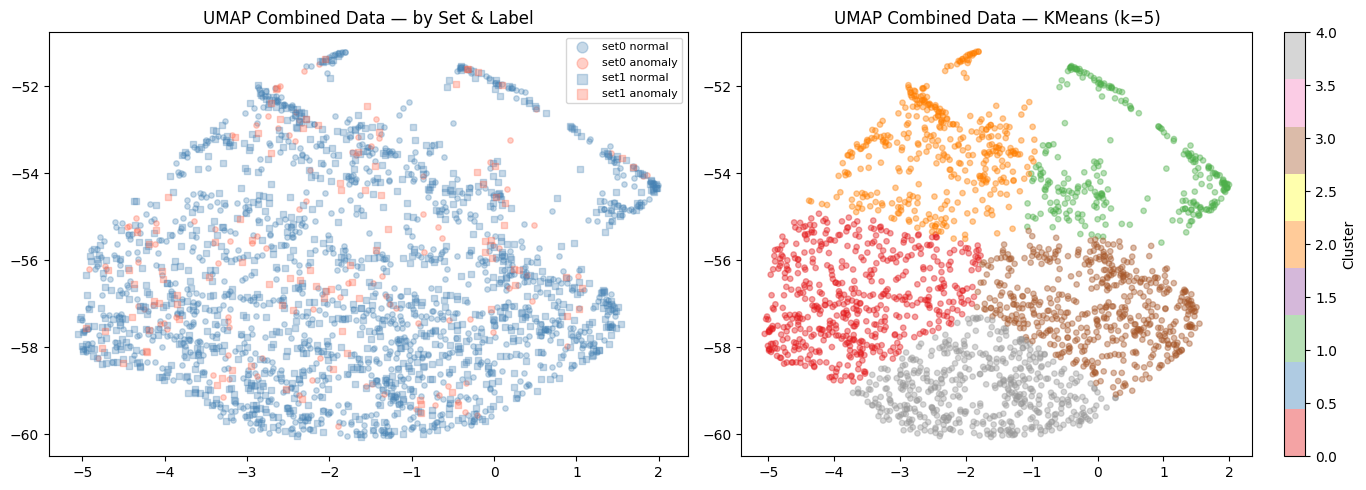

UMAP cluster composition:
  Cluster 0: 467 normal, 65 anomaly (30 set0, 35 set1)
  Cluster 1: 238 normal, 24 anomaly (11 set0, 13 set1)
  Cluster 2: 337 normal, 42 anomaly (20 set0, 22 set1)
  Cluster 3: 487 normal, 35 anomaly (19 set0, 16 set1)
  Cluster 4: 471 normal, 34 anomaly (20 set0, 14 set1)


In [27]:
# UMAP on all data
umap_all = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_all_umap = umap_all.fit_transform(X_pca[:, :20])  # Use top 20 PCs for speed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By label + source set
for src, marker in [('set0', 'o'), ('set1', 's')]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[0].scatter(X_all_umap[mask, 0], X_all_umap[mask, 1],
                       c=color, marker=marker, alpha=0.3, s=15, label=lbl)
axes[0].set_title('UMAP Combined Data — by Set & Label')
axes[0].legend(markerscale=2, fontsize=8)

# KMeans k=5 on all data (1 normal + 4 anomaly types)
km_all_umap = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_all_umap = km_all_umap.fit_predict(X_all_umap)
scatter = axes[1].scatter(X_all_umap[:, 0], X_all_umap[:, 1],
                          c=clusters_all_umap, cmap='Set1', alpha=0.4, s=15)
axes[1].set_title('UMAP Combined Data — KMeans (k=5)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Cluster composition
print("UMAP cluster composition:")
for c in range(5):
    mask = clusters_all_umap == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == 'set0') & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == 'set1') & (y_all[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1)")

## 8. SVD Compression + Feature Importance

TruncatedSVD works directly on sparse data. Also look at which features differ most between normal and anomaly.